In [1]:
# Install required libraries (run once in Colab or new environments)
!pip install transformers datasets scikit-learn torch torchvision torchaudio --quiet
!pip install kaggle --quiet

 Section 1: Import Libraries

In [2]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# ── Hugging Face Transformers ─────────────────────────────────────────────────
from transformers import (
    BertTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# ── Scikit-learn Metrics ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device Configuration ──────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {DEVICE}")
print(f"✅ PyTorch version: {torch.__version__}")

✅ Using device: cuda
✅ PyTorch version: 2.10.0+cu128


 Section 2: Load Dataset


> **Kaggle link:** https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [3]:
# ── Option A: Load via Hugging Face datasets (recommended for Colab) ──────────
from datasets import load_dataset

print("⏳ Loading IMDB dataset from Hugging Face...")
raw_dataset = load_dataset("imdb")

# Convert to pandas DataFrames for easier preprocessing
train_df = pd.DataFrame(raw_dataset['train'])
test_df  = pd.DataFrame(raw_dataset['test'])

# Combine for a fresh stratified split later
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"✅ Total samples loaded: {len(df)}")
print(f"   Columns: {df.columns.tolist()}")
df.head()

⏳ Loading IMDB dataset from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ Total samples loaded: 50000
   Columns: ['text', 'label']


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


── Shape: (50000, 2)
── Null values:
 text     0
label    0
dtype: int64
── Label distribution:
label
0    25000
1    25000
Name: count, dtype: int64


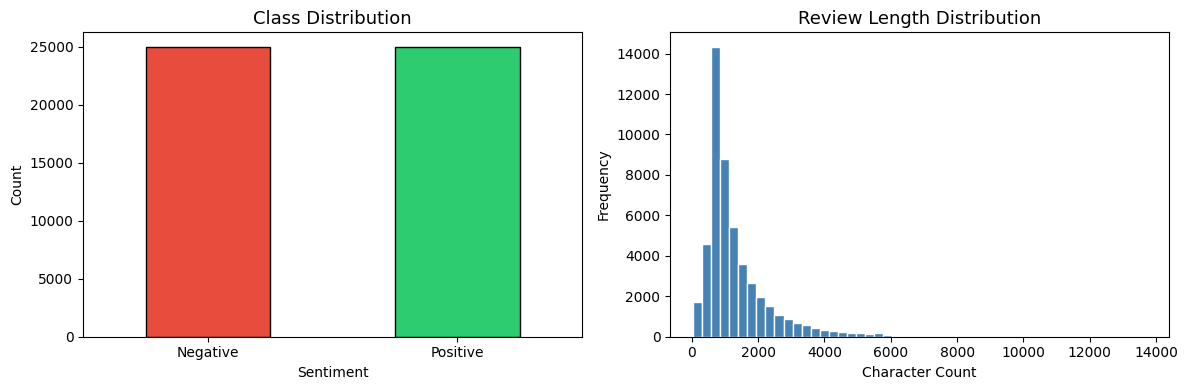

In [4]:
# ── Basic EDA ─────────────────────────────────────────────────────────────────
print("── Shape:", df.shape)
print("── Null values:\n", df.isnull().sum())
print("── Label distribution:")
print(df['label'].value_counts())

# Map numeric labels to readable names for reference
# 0 → Negative, 1 → Positive
label_map = {0: 'Negative', 1: 'Positive'}
df['sentiment'] = df['label'].map(label_map)

# Visualise class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['#E74C3C','#2ECC71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['text'].str.len().plot(kind='hist', bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Review Length Distribution', fontsize=13)
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

 Section 3: Data Preprocessing

In [5]:
def clean_text(text: str) -> str:
    """
    Clean raw review text:
    1. Remove HTML tags (common in IMDB reviews)
    2. Remove special characters / punctuation noise
    3. Collapse multiple whitespaces
    4. Strip leading / trailing whitespace
    """
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # Keep only alphanumeric and basic punctuation
    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", ' ', text)
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()


print("⏳ Cleaning text...")
df['clean_text'] = df['text'].apply(clean_text)

# Drop any rows where cleaning resulted in empty strings
df = df[df['clean_text'].str.len() > 10].reset_index(drop=True)

print(f"✅ Cleaned dataset size: {len(df)}")
print("\n── Sample cleaned review:")
print(df['clean_text'].iloc[0][:300], "...")

⏳ Cleaning text...
✅ Cleaned dataset size: 50000

── Sample cleaned review:
i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered controversial i really had ...


 Section 4: Train / Validation / Test Split

In [6]:
# ── For faster experimentation, sample 6000 rows (2000 per split) ─────────────
# Remove this sampling block to train on the full 50 k dataset
df_sample = df.sample(n=6000, random_state=SEED).reset_index(drop=True)

# ── Stratified split: 70% train | 15% validation | 15% test ──────────────────
X = df_sample['clean_text'].values
y = df_sample['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train size      : {len(X_train)}")
print(f"Validation size : {len(X_val)}")
print(f"Test size       : {len(X_test)}")

Train size      : 4200
Validation size : 900
Test size       : 900


 Section 5: Tokenization with `bert-base-uncased`

In [7]:
MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 256   # BERT max is 512; 256 covers most reviews and saves memory

print(f"⏳ Loading tokenizer: {MODEL_NAME}")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# ── Custom PyTorch Dataset ────────────────────────────────────────────────────
class IMDBDataset(Dataset):
    """
    PyTorch Dataset wrapper that tokenizes text on-the-fly.
    Returns input_ids, attention_mask, and label tensors.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Tokenize and encode the text
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),        # (max_len,)
            'attention_mask': encoding['attention_mask'].squeeze(0),   # (max_len,)
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ── Create Dataset objects ────────────────────────────────────────────────────
train_dataset = IMDBDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = IMDBDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = IMDBDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Tokenizer loaded | MAX_LEN={MAX_LEN} | BATCH_SIZE={BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

⏳ Loading tokenizer: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded | MAX_LEN=256 | BATCH_SIZE=16
   Train batches: 263 | Val batches: 57 | Test batches: 57


Section 6: Helper Functions – Training & Evaluation

In [8]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """Run one full training epoch; return average loss."""
    model.train()
    total_loss = 0.0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()  # Clear gradients from previous step

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()             # Back-propagation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()            # Update weights
        scheduler.step()            # Update learning rate

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, device):
    """Evaluate model; return loss, accuracy, and all predictions + true labels."""
    model.eval()
    total_loss  = 0.0
    all_preds   = []
    all_labels  = []

    with torch.no_grad():  # No gradient computation during evaluation
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)  # Pick class with highest logit
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy, all_preds, all_labels


def compute_metrics(y_true, y_pred, label_names=None):
    """Compute and print full classification metrics."""
    label_names = label_names or ['Negative', 'Positive']
    print("\n── Classification Report ──────────────────────────")
    print(classification_report(y_true, y_pred, target_names=label_names))
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted'),
        'recall'   : recall_score(y_true, y_pred, average='weighted'),
        'f1'       : f1_score(y_true, y_pred, average='weighted')
    }


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    """Plot a styled confusion matrix using seaborn."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive']
    )
    plt.title(title, fontsize=14)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()


def plot_training_curves(train_losses, val_losses, val_accuracies, title=''):
    """Plot loss and accuracy curves over epochs."""
    epochs = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, train_losses, 'o-', label='Train Loss', color='#E74C3C')
    axes[0].plot(epochs, val_losses,   's-', label='Val Loss',   color='#3498DB')
    axes[0].set_title(f'Loss Curve – {title}', fontsize=12)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, val_accuracies, 'D-', label='Val Accuracy', color='#2ECC71')
    axes[1].set_title(f'Validation Accuracy – {title}', fontsize=12)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print("✅ Helper functions defined.")

✅ Helper functions defined.


 Section 7: Experiment 1 – Frozen BERT (Train Classifier Head Only)

**Strategy:** Freeze all BERT encoder layers. Only the final classification layer is updated.  
**Use case:** Quick baseline; minimal compute; treats BERT as a static feature extractor.

In [9]:
# ── Load pre-trained BERT for sequence classification ─────────────────────────
print(f"⏳ Loading {MODEL_NAME} for Experiment 1...")
model_exp1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2   # Binary: Negative (0) / Positive (1)
).to(DEVICE)

# ── FREEZE all BERT layers ────────────────────────────────────────────────────
for name, param in model_exp1.bert.named_parameters():
    param.requires_grad = False   # Freeze encoder weights

# Count trainable vs total parameters
total_params     = sum(p.numel() for p in model_exp1.parameters())
trainable_params = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
print(f"   Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,} (classifier head only)")

⏳ Loading bert-base-uncased for Experiment 1...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Total parameters    : 109,483,778
   Trainable parameters: 1,538 (classifier head only)



🚀 Experiment 1: Training (Frozen BERT)
  Epoch 1/3 | Train Loss: 0.6765 | Val Loss: 0.6734 | Val Acc: 0.5922


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ (improved & saved)
  Epoch 2/3 | Train Loss: 0.6692 | Val Loss: 0.6702 | Val Acc: 0.6044


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ (improved & saved)
  Epoch 3/3 | Train Loss: 0.6712 | Val Loss: 0.6682 | Val Acc: 0.6289


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ (improved & saved)


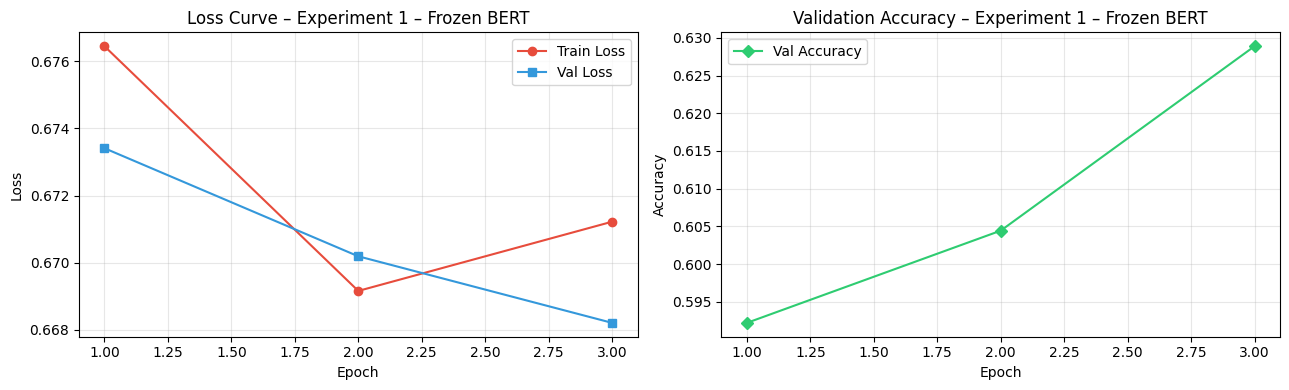

In [28]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS_EXP1 = 3
LR          = 2e-5

# AdamW optimizer with weight decay (avoids over-fitting)
optimizer_exp1 = AdamW(filter(lambda p: p.requires_grad, model_exp1.parameters()),
                       lr=LR, weight_decay=0.01)

# Linear warmup scheduler (10% of total steps as warmup)
total_steps_exp1  = len(train_loader) * EPOCHS_EXP1
warmup_steps_exp1 = int(0.1 * total_steps_exp1)
scheduler_exp1 = get_linear_schedule_with_warmup(
    optimizer_exp1,
    num_warmup_steps=warmup_steps_exp1,
    num_training_steps=total_steps_exp1
)

# ── Training loop ─────────────────────────────────────────────────────────────
train_losses_exp1 = []
val_losses_exp1   = []
val_accs_exp1     = []
best_val_loss = float('inf')   # add this BEFORE loop (once)

print("\n🚀 Experiment 1: Training (Frozen BERT)")
print("="*50)

for epoch in range(1, EPOCHS_EXP1 + 1):
    tr_loss = train_epoch(model_exp1, train_loader, optimizer_exp1, scheduler_exp1, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(model_exp1, val_loader, DEVICE)

    train_losses_exp1.append(tr_loss)
    val_losses_exp1.append(vl_loss)
    val_accs_exp1.append(vl_acc)

    print(f"  Epoch {epoch}/{EPOCHS_EXP1} | Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.4f}")
    if vl_loss < best_val_loss:
      best_val_loss  = vl_loss
      patience_count = 0

      # ✅ SAVE BEST MODEL
      model_exp1.save_pretrained("best_model_exp1")
      tokenizer.save_pretrained("best_model_exp1")

      print("  ✅ (improved & saved)")


plot_training_curves(train_losses_exp1, val_losses_exp1, val_accs_exp1, 'Experiment 1 – Frozen BERT')


── Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Negative       0.64      0.36      0.47       453
    Positive       0.55      0.80      0.65       447

    accuracy                           0.58       900
   macro avg       0.60      0.58      0.56       900
weighted avg       0.60      0.58      0.56       900



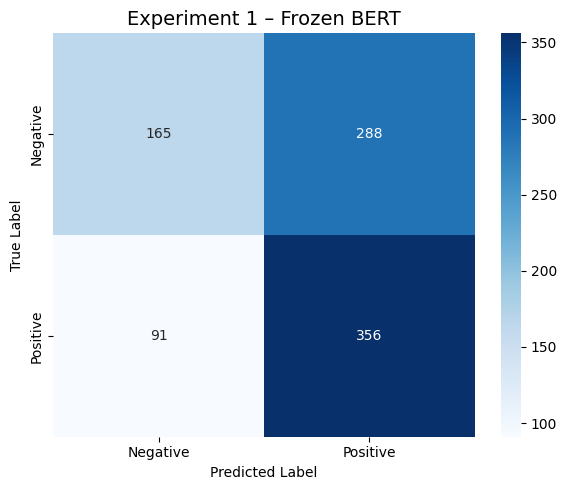


✅ Test Accuracy (Exp 1): 0.5789


In [29]:
# ── Test-set evaluation for Experiment 1 ─────────────────────────────────────
_, test_acc_exp1, preds_exp1, labels_exp1 = evaluate(model_exp1, test_loader, DEVICE)
metrics_exp1 = compute_metrics(labels_exp1, preds_exp1)
plot_confusion_matrix(labels_exp1, preds_exp1, title='Experiment 1 – Frozen BERT')
print(f"\n✅ Test Accuracy (Exp 1): {test_acc_exp1:.4f}")

 Section 8: Experiment 2 – Fine-Tune Last 2 BERT Layers


In [30]:
print(f"⏳ Loading {MODEL_NAME} for Experiment 2...")
model_exp2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

# ── Freeze ALL BERT layers first ──────────────────────────────────────────────
for param in model_exp2.bert.parameters():
    param.requires_grad = False

# ── Unfreeze last 2 transformer encoder layers (layers 10 and 11) ─────────────
# BERT-base has 12 encoder layers (indexed 0–11)
for layer_idx in [10, 11]:
    for param in model_exp2.bert.encoder.layer[layer_idx].parameters():
        param.requires_grad = True

# Also unfreeze the pooler (feeds into classifier)
for param in model_exp2.bert.pooler.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
print(f"   Trainable parameters: {trainable_params:,} (last 2 layers + pooler + classifier)")

⏳ Loading bert-base-uncased for Experiment 2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Trainable parameters: 14,767,874 (last 2 layers + pooler + classifier)



🚀 Experiment 2: Training (Last 2 Layers + Classifier)
  Epoch 1/3 | Train Loss: 0.4590 | Val Loss: 0.2469 | Val Acc: 0.9000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved!
  Epoch 2/3 | Train Loss: 0.2689 | Val Loss: 0.2787 | Val Acc: 0.8900
  Epoch 3/3 | Train Loss: 0.2385 | Val Loss: 0.2230 | Val Acc: 0.9067


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved!


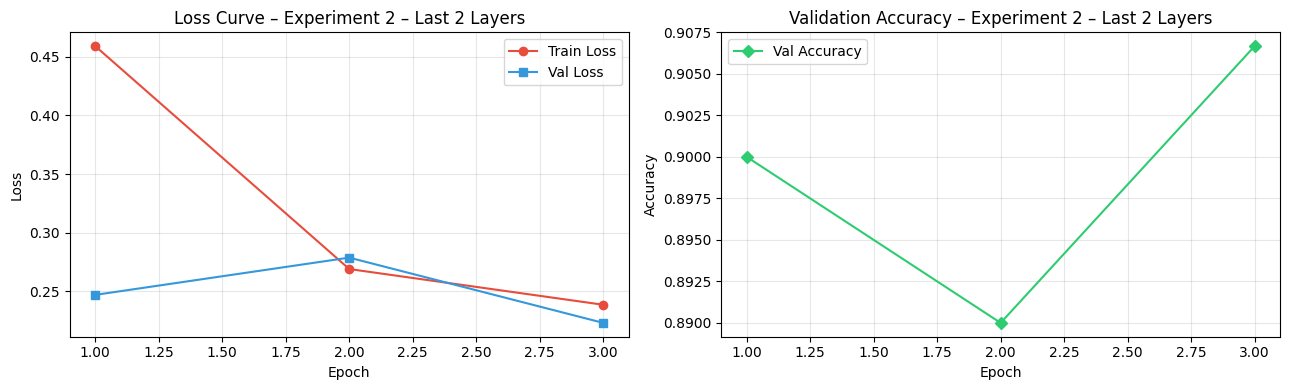

In [31]:
EPOCHS_EXP2    = 3
optimizer_exp2 = AdamW(filter(lambda p: p.requires_grad, model_exp2.parameters()),
                       lr=LR, weight_decay=0.01)

total_steps_exp2  = len(train_loader) * EPOCHS_EXP2
warmup_steps_exp2 = int(0.1 * total_steps_exp2)
scheduler_exp2 = get_linear_schedule_with_warmup(
    optimizer_exp2,
    num_warmup_steps=warmup_steps_exp2,
    num_training_steps=total_steps_exp2
)

train_losses_exp2 = []
val_losses_exp2   = []
val_accs_exp2     = []

best_val_loss = float('inf')   # ✅ ADD THIS

print("\n🚀 Experiment 2: Training (Last 2 Layers + Classifier)")
print("="*50)

for epoch in range(1, EPOCHS_EXP2 + 1):
    tr_loss = train_epoch(model_exp2, train_loader, optimizer_exp2, scheduler_exp2, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(model_exp2, val_loader, DEVICE)

    train_losses_exp2.append(tr_loss)
    val_losses_exp2.append(vl_loss)
    val_accs_exp2.append(vl_acc)

    print(f"  Epoch {epoch}/{EPOCHS_EXP2} | Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.4f}")

    # ✅ SAVE BEST MODEL
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss

        model_exp2.save_pretrained("best_model_exp2")
        tokenizer.save_pretrained("best_model_exp2")

        print("  ✅ Best model saved!")

plot_training_curves(train_losses_exp2, val_losses_exp2, val_accs_exp2, 'Experiment 2 – Last 2 Layers')


── Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89       453
    Positive       0.89      0.89      0.89       447

    accuracy                           0.89       900
   macro avg       0.89      0.89      0.89       900
weighted avg       0.89      0.89      0.89       900



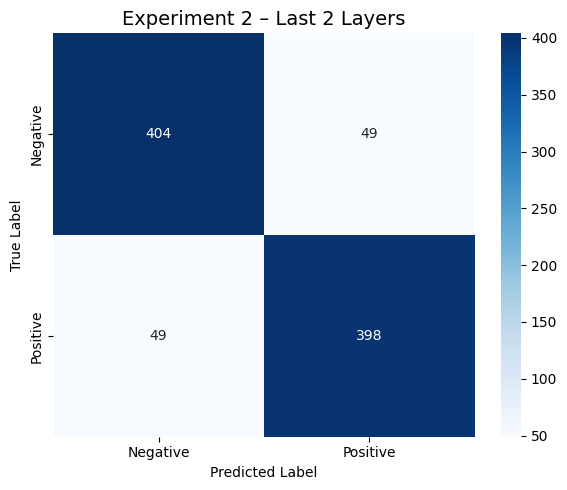


✅ Test Accuracy (Exp 2): 0.8911


In [32]:
_, test_acc_exp2, preds_exp2, labels_exp2 = evaluate(model_exp2, test_loader, DEVICE)
metrics_exp2 = compute_metrics(labels_exp2, preds_exp2)
plot_confusion_matrix(labels_exp2, preds_exp2, title='Experiment 2 – Last 2 Layers')
print(f"\n✅ Test Accuracy (Exp 2): {test_acc_exp2:.4f}")

 Section 9: Experiment 3 – Full BERT Fine-Tuning (All Layers)

**Strategy:** Unfreeze all BERT layers and fine-tune end-to-end.  
**Use case:** Best possible performance; requires more compute and careful LR tuning.

In [33]:
print(f"⏳ Loading {MODEL_NAME} for Experiment 3 (Full Fine-Tune)...")
model_exp3 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

# All parameters are trainable by default in HF models
trainable_params = sum(p.numel() for p in model_exp3.parameters() if p.requires_grad)
print(f"   Trainable parameters: {trainable_params:,} (ALL layers)")

⏳ Loading bert-base-uncased for Experiment 3 (Full Fine-Tune)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Trainable parameters: 109,483,778 (ALL layers)



🚀 Experiment 3: Full Fine-Tuning (All Layers)
  Epoch 1/3 | Train Loss: 0.4261 | Val Loss: 0.2303 | Val Acc: 0.9078


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ (improved & saved)
  Epoch 2/3 | Train Loss: 0.2062 | Val Loss: 0.2400 | Val Acc: 0.9122
  Epoch 3/3 | Train Loss: 0.1143 | Val Loss: 0.3088 | Val Acc: 0.9133


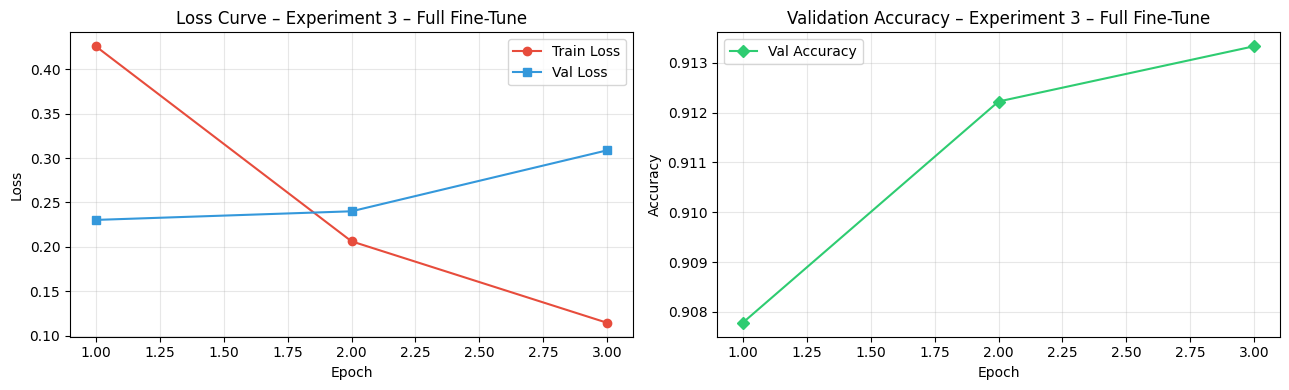

In [34]:

EPOCHS_EXP3    = 3
optimizer_exp3 = AdamW(model_exp3.parameters(), lr=LR, weight_decay=0.01)

total_steps_exp3  = len(train_loader) * EPOCHS_EXP3
warmup_steps_exp3 = int(0.1 * total_steps_exp3)
scheduler_exp3 = get_linear_schedule_with_warmup(
    optimizer_exp3,
    num_warmup_steps=warmup_steps_exp3,
    num_training_steps=total_steps_exp3
)

train_losses_exp3 = []
val_losses_exp3   = []
val_accs_exp3     = []
best_val_loss = float('inf')

print("\n🚀 Experiment 3: Full Fine-Tuning (All Layers)")
print("="*50)

for epoch in range(1, EPOCHS_EXP3 + 1):
    tr_loss = train_epoch(model_exp3, train_loader, optimizer_exp3, scheduler_exp3, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(model_exp3, val_loader, DEVICE)

    train_losses_exp3.append(tr_loss)
    val_losses_exp3.append(vl_loss)
    val_accs_exp3.append(vl_acc)

    print(f"  Epoch {epoch}/{EPOCHS_EXP3} | Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.4f}")

    if vl_loss < best_val_loss:
      best_val_loss  = vl_loss

      # ✅ SAVE BEST MODEL
      model_exp3.save_pretrained("best_model_exp3")
      tokenizer.save_pretrained("best_model_exp3")

      print("  ✅ (improved & saved)")


plot_training_curves(train_losses_exp3, val_losses_exp3, val_accs_exp3, 'Experiment 3 – Full Fine-Tune')


── Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Negative       0.89      0.93      0.91       453
    Positive       0.93      0.89      0.91       447

    accuracy                           0.91       900
   macro avg       0.91      0.91      0.91       900
weighted avg       0.91      0.91      0.91       900



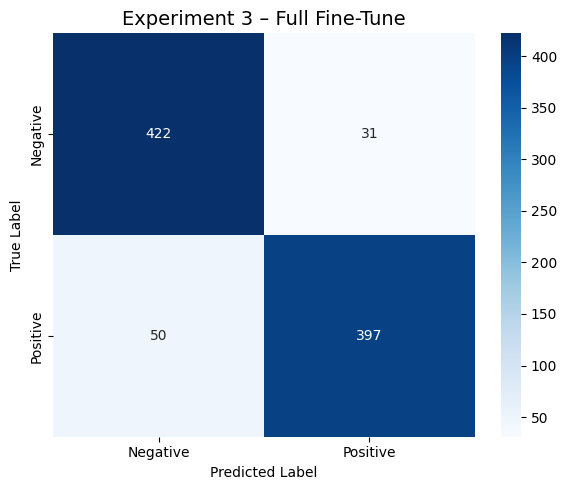


✅ Test Accuracy (Exp 3): 0.9100


In [35]:
_, test_acc_exp3, preds_exp3, labels_exp3 = evaluate(model_exp3, test_loader, DEVICE)
metrics_exp3 = compute_metrics(labels_exp3, preds_exp3)
plot_confusion_matrix(labels_exp3, preds_exp3, title='Experiment 3 – Full Fine-Tune')
print(f"\n✅ Test Accuracy (Exp 3): {test_acc_exp3:.4f}")

 Section 10: Comparison of All Experiments


📊 Experiment Comparison Table
                       Accuracy  Precision  Recall  F1 Score
Experiment                                                  
Exp 1: Frozen BERT       0.5789     0.5990  0.5789    0.5584
Exp 2: Last 2 Layers     0.8911     0.8911  0.8911    0.8911
Exp 3: Full Fine-Tune    0.9100     0.9107  0.9100    0.9099


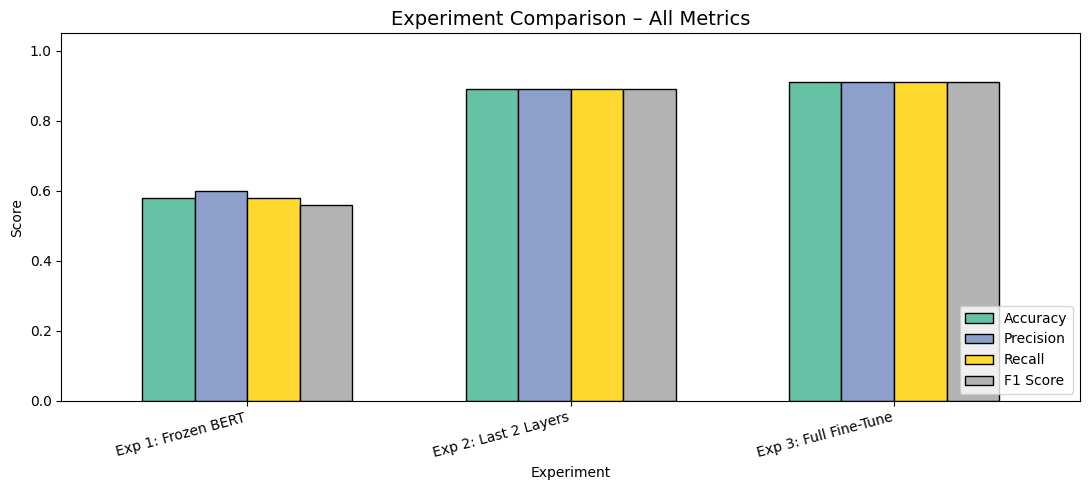

In [36]:
# ── Build a comparison DataFrame ──────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Experiment': [
        'Exp 1: Frozen BERT',
        'Exp 2: Last 2 Layers',
        'Exp 3: Full Fine-Tune'
    ],
    'Accuracy' : [metrics_exp1['accuracy'],  metrics_exp2['accuracy'],  metrics_exp3['accuracy']],
    'Precision': [metrics_exp1['precision'], metrics_exp2['precision'], metrics_exp3['precision']],
    'Recall'   : [metrics_exp1['recall'],    metrics_exp2['recall'],    metrics_exp3['recall']],
    'F1 Score' : [metrics_exp1['f1'],        metrics_exp2['f1'],        metrics_exp3['f1']]
})
comparison_df = comparison_df.set_index('Experiment').round(4)

print("\n📊 Experiment Comparison Table")
print("="*60)
print(comparison_df.to_string())

# ── Bar chart comparison ───────────────────────────────────────────────────────
comparison_df.plot(
    kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='black', width=0.65
)
plt.title('Experiment Comparison – All Metrics', fontsize=14)
plt.xlabel('Experiment')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Section 11: Bonus – DistilBERT with Learning Rate Scheduler & Early Stopping

**DistilBERT** is a lighter, faster distilled version of BERT (40% fewer parameters, ~60% faster).

In [37]:
from transformers import DistilBertTokenizer, AutoModelForSequenceClassification

DISTIL_MODEL = 'distilbert-base-uncased'

print(f"⏳ Loading DistilBERT tokenizer: {DISTIL_MODEL}")
distil_tokenizer = DistilBertTokenizer.from_pretrained(DISTIL_MODEL)

# Re-create datasets with DistilBERT tokenizer
train_dataset_d = IMDBDataset(X_train, y_train, distil_tokenizer, MAX_LEN)
val_dataset_d   = IMDBDataset(X_val,   y_val,   distil_tokenizer, MAX_LEN)
test_dataset_d  = IMDBDataset(X_test,  y_test,  distil_tokenizer, MAX_LEN)

train_loader_d  = DataLoader(train_dataset_d, batch_size=BATCH_SIZE, shuffle=True)
val_loader_d    = DataLoader(val_dataset_d,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_d   = DataLoader(test_dataset_d,  batch_size=BATCH_SIZE, shuffle=False)

model_distil = AutoModelForSequenceClassification.from_pretrained(
    DISTIL_MODEL, num_labels=2
).to(DEVICE)

print(f"✅ DistilBERT loaded | Trainable params: {sum(p.numel() for p in model_distil.parameters() if p.requires_grad):,}")

⏳ Loading DistilBERT tokenizer: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ DistilBERT loaded | Trainable params: 66,955,010



🚀 Bonus: DistilBERT Full Fine-Tuning with Early Stopping
  Epoch 1/4 | Train Loss: 0.4403 | Val Loss: 0.2412 | Val Acc: 0.9056  ✅ (improved)
  Epoch 2/4 | Train Loss: 0.2339 | Val Loss: 0.2417 | Val Acc: 0.9033  ⚠️ No improvement (1/2)
  Epoch 3/4 | Train Loss: 0.1246 | Val Loss: 0.3328 | Val Acc: 0.9000  ⚠️ No improvement (2/2)
  🛑 Early stopping triggered.


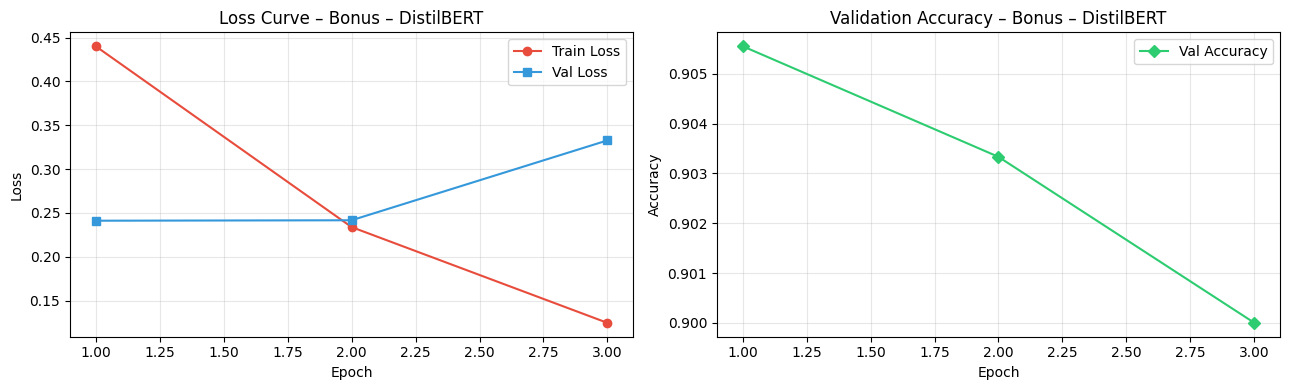


── Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Negative       0.89      0.93      0.91       453
    Positive       0.93      0.88      0.90       447

    accuracy                           0.91       900
   macro avg       0.91      0.91      0.91       900
weighted avg       0.91      0.91      0.91       900



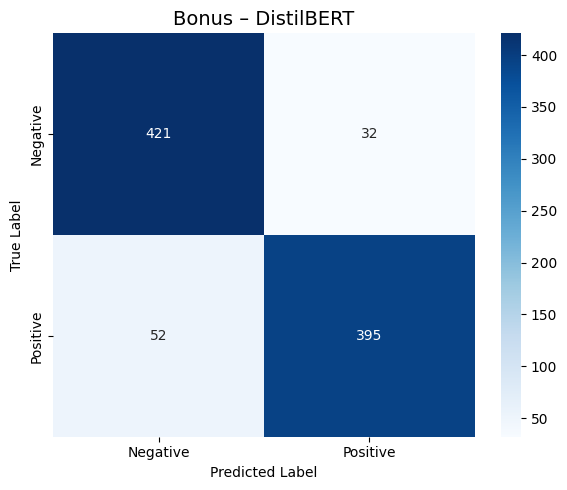


✅ DistilBERT Test Accuracy: 0.9067


In [38]:
from torch.cuda.amp import autocast, GradScaler

EPOCHS_DISTIL  = 3
PATIENCE       = 2

optimizer_distil = AdamW(model_distil.parameters(), lr=LR, weight_decay=0.01)

total_steps_d    = len(train_loader_d) * EPOCHS_DISTIL
scheduler_distil = get_linear_schedule_with_warmup(
    optimizer_distil,
    num_warmup_steps=int(0.1 * total_steps_d),
    num_training_steps=total_steps_d
)

train_losses_distil = []
val_losses_distil   = []
val_accs_distil     = []

best_val_loss   = float('inf')
patience_count  = 0

scaler = GradScaler()

print("\n🚀 Bonus: DistilBERT Full Fine-Tuning (Optimized)")
print("="*55)

for epoch in range(1, EPOCHS_DISTIL + 1):

    model_distil.train()
    total_loss = 0

    for batch in train_loader_d:
        optimizer_distil.zero_grad()

        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        with autocast():
            outputs = model_distil(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer_distil)
        scaler.update()
        scheduler_distil.step()

        total_loss += loss.item()

    tr_loss = total_loss / len(train_loader_d)

    vl_loss, vl_acc, _, _ = evaluate(model_distil, val_loader_d, DEVICE)

    train_losses_distil.append(tr_loss)
    val_losses_distil.append(vl_loss)
    val_accs_distil.append(vl_acc)

    print(f"  Epoch {epoch}/{EPOCHS_DISTIL} | Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.4f}", end="")

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        patience_count = 0

        model_distil.save_pretrained("best_model")
        tokenizer.save_pretrained("best_model")

        print("  ✅ (improved & saved)")
    else:
        patience_count += 1
        print(f"  ⚠️ No improvement ({patience_count}/{PATIENCE})")

        if patience_count >= PATIENCE:
            print("  🛑 Early stopping triggered.")
            break


plot_training_curves(train_losses_distil, val_losses_distil, val_accs_distil, 'Bonus – DistilBERT')

_, test_acc_distil, preds_distil, labels_distil = evaluate(model_distil, test_loader_d, DEVICE)
metrics_distil = compute_metrics(labels_distil, preds_distil)
plot_confusion_matrix(labels_distil, preds_distil, title='Bonus – DistilBERT')

print(f"\n✅ DistilBERT Test Accuracy: {test_acc_distil:.4f}")

 Section 12: Final Summary & Analysis

In [42]:
final_df = pd.DataFrame({
    'Model / Experiment': [
        'BERT – Frozen (Exp 1)',
        'BERT – Last 2 Layers (Exp 2)',
        'BERT – Full Fine-Tune (Exp 3)',
        'DistilBERT – Full Fine-Tune (Bonus)'
    ],
    'Accuracy' : [metrics_exp1['accuracy'],  metrics_exp2['accuracy'],  metrics_exp3['accuracy'],  metrics_distil['accuracy']],
    'Precision': [metrics_exp1['precision'], metrics_exp2['precision'], metrics_exp3['precision'], metrics_distil['precision']],
    'Recall'   : [metrics_exp1['recall'],    metrics_exp2['recall'],    metrics_exp3['recall'],    metrics_distil['recall']],
    'F1 Score' : [metrics_exp1['f1'],        metrics_exp2['f1'],        metrics_exp3['f1'],        metrics_distil['f1']]
}).set_index('Model / Experiment').round(4)

print("\n🏆 FINAL COMPARISON TABLE")
print("="*70)
print(final_df.to_string())


🏆 FINAL COMPARISON TABLE
                                     Accuracy  Precision  Recall  F1 Score
Model / Experiment                                                        
BERT – Frozen (Exp 1)                  0.5789     0.5990  0.5789    0.5584
BERT – Last 2 Layers (Exp 2)           0.8911     0.8911  0.8911    0.8911
BERT – Full Fine-Tune (Exp 3)          0.9100     0.9107  0.9100    0.9099
DistilBERT – Full Fine-Tune (Bonus)    0.9067     0.9074  0.9067    0.9066


In [44]:
!pip install nbformat

In [41]:
# 🔍 Find best model based on F1 Score (recommended)
best_model_name = final_df['F1 Score'].idxmax()

print("\n🏆 Best Model Selected:", best_model_name)

# =========================
# SAVE BEST MODEL
# =========================

if best_model_name == 'BERT – Frozen (Exp 1)':
    model_exp1.save_pretrained("final_best_model")
    tokenizer.save_pretrained("final_best_model")

elif best_model_name == 'BERT – Last 2 Layers (Exp 2)':
    model_exp2.save_pretrained("final_best_model")
    tokenizer.save_pretrained("final_best_model")

elif best_model_name == 'BERT – Full Fine-Tune (Exp 3)':
    model_exp3.save_pretrained("final_best_model")
    tokenizer.save_pretrained("final_best_model")

elif best_model_name == 'DistilBERT – Full Fine-Tune (Bonus)':
    model_distil.save_pretrained("final_best_model")
    tokenizer.save_pretrained("final_best_model")

print("✅ Final best model saved as 'final_best_model'")


🏆 Best Model Selected: BERT – Full Fine-Tune (Exp 3)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Final best model saved as 'final_best_model'


In [43]:
# Install Gradio (Colab only)
!pip install gradio -q

# Imports
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import gradio as gr

# ✅ LOAD FINAL BEST MODEL (UPDATED)
model = AutoModelForSequenceClassification.from_pretrained("final_best_model")
tokenizer = AutoTokenizer.from_pretrained("final_best_model")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Prediction function
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()

    label = "Positive 😊" if pred == 1 else "Negative 😡"

    return f"{label} (Confidence: {confidence:.2f})"

# Gradio UI
interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Enter movie review..."),
    outputs="text",
    title="🎬 Sentiment Analysis (Final Best Model)",
    description="Using best model selected based on F1 Score from all experiments"
)

# Launch
interface.launch()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e21a7ea429363712e1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
